# Fate knocking — Symphony No. 5's opening, scored as a storm

Same principle as `ode_to_joy_landscape.ipynb` (the score itself is the instruction, no audio, no pitch-detection, no copyright question — the composition is public domain and we never touch a specific recording), but the opposite musical character calls for the opposite visual language.

The Ode to Joy passage builds gradually (quiet cello alone -> full orchestra) which mapped onto a landscape's gentle dawn. This motif is the opposite: **tutti unison forte from the very first note** — no gradual entrance, no dynamic build. What actually varies is pitch (G-G-G-E&#9837;, then F-F-F-D, the second phrase answering a step lower) and duration (three quick notes, then one long fermata note that "hangs in the air," per Michael Steinberg's famous description of these as "eight notes... three quick notes plus one that is lower and much longer, in fact unmeasured"). That's a lightning strike, not a sunrise: quick jabs that flash and don't quite land, then one strike that plunges down and floods the ground — then a duller echo of the same shape, one step lower.

Pitches (G-G-G-E&#9837;, F-F-F-D) were verified against the historical record before encoding, same discipline as the Ode to Joy piece.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

NOTE_SEMITONE = {"C": 0, "D": 2, "Eb": 3, "E": 4, "F": 5, "G": 7, "A": 9, "B": 11}

# the famous "eight notes": ta-ta-ta-TAAA, ta-ta-ta-TAAA (Steinberg's phrase)
NOTES = [("G", False), ("G", False), ("G", False), ("Eb", True),
         ("F", False), ("F", False), ("F", False), ("D", True)]

SHORT_DUR = 0.35
LONG_DUR = 1.5
REST_BETWEEN_PHRASES = 0.6
TRAIL = 1.0  # dark runout after the last note, implying the piece keeps going

events = []
x = 0.3
for i, (pitch, is_long) in enumerate(NOTES):
    dur = LONG_DUR if is_long else SHORT_DUR
    events.append({"x": x + dur / 2, "pitch": pitch, "is_long": is_long, "dur": dur})
    x += dur
    if i == 3:  # rest between the two phrases
        x += REST_BETWEEN_PHRASES
WIDTH = x + TRAIL

SEMITONES = np.array([NOTE_SEMITONE[e["pitch"]] for e in events], dtype=float)
PITCH_NORM = (SEMITONES - SEMITONES.min()) / (SEMITONES.max() - SEMITONES.min())  # 0..1, 0=lowest

SKY_TOP = np.array([0.03, 0.03, 0.06])
SKY_BOTTOM = np.array([0.07, 0.08, 0.13])
FLASH_COLOR = np.array([0.85, 0.92, 1.0])

## Render: sky, silhouette, and each strike

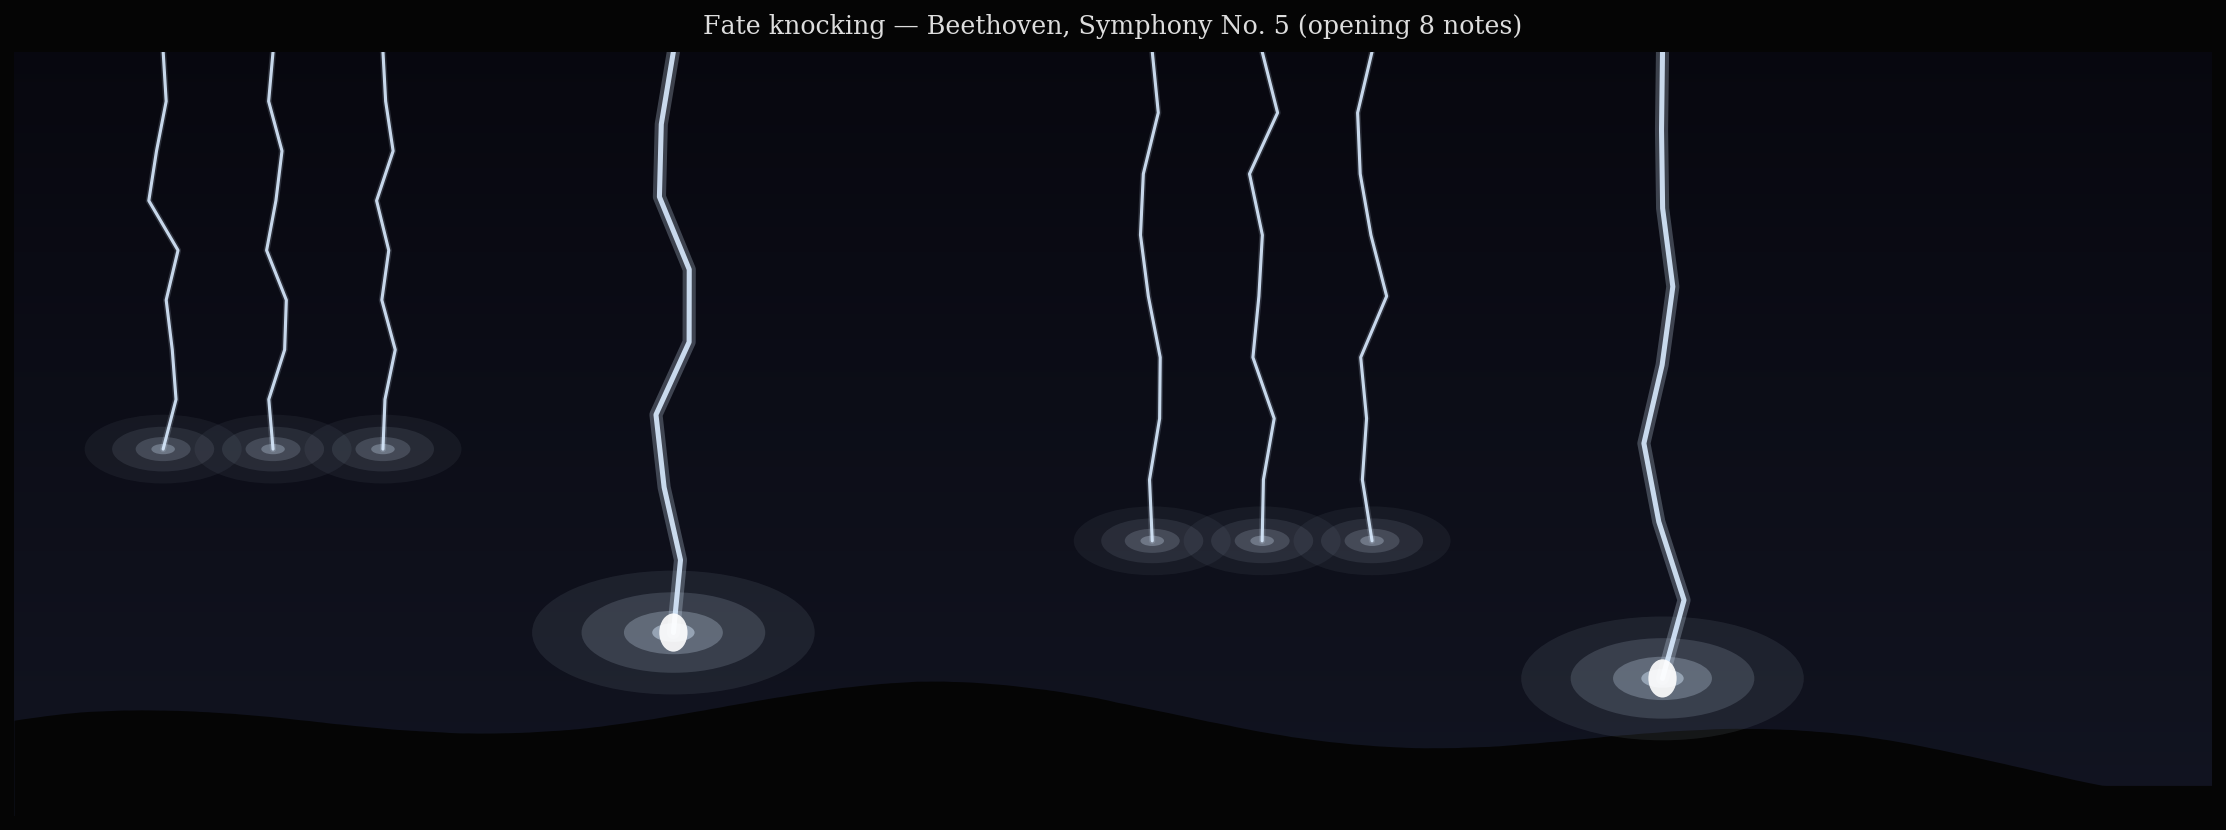

saved fate_motif_storm.png


In [2]:
def make_bolt(rng, x0, y_top, y_bottom, n_segments=9, jitter=0.045):
    ys = np.linspace(y_top, y_bottom, n_segments)
    xs = x0 + rng.uniform(-jitter, jitter, n_segments)
    xs[0] = x0
    xs[-1] = x0  # strike point stays put, only the middle wanders
    return xs, ys


def draw_sky(ax):
    grad = np.linspace(SKY_TOP, SKY_BOTTOM, 300).reshape(300, 1, 3)
    ax.imshow(grad, extent=(0, WIDTH, 0, 1), origin="upper", aspect="auto", zorder=0)


def draw_silhouette(ax, n_points=500, seed=7):
    rng = np.random.default_rng(seed)
    xs = np.linspace(0, WIDTH, n_points)
    ridge = 0.10 + 0.05 * np.sin(xs * 0.6) + 0.03 * np.sin(xs * 2.3 + 1.0)
    ridge += rng.normal(0, 0.01, n_points).cumsum() * 0.01
    ridge = np.clip(ridge, 0.04, None)
    ax.fill_between(xs, 0, ridge, color="#050505", zorder=5, linewidth=0)


def light_pool(ax, x0, ground_y, strength, width_scale):
    # a squat puddle of light, sized in x/y data-units independently -- a plain Circle
    # gets stretched into a tall egg on these non-square axes
    base_w, base_h = 0.5 * width_scale, 0.09 * width_scale
    for scale, a in [(1.0, 0.05), (0.65, 0.09), (0.35, 0.16), (0.15, 0.28)]:
        ax.add_patch(Ellipse((x0, ground_y), base_w * scale, base_h * scale,
                              color=tuple(FLASH_COLOR), alpha=a * strength, zorder=6, linewidth=0))


def draw_events(ax):
    for i, (e, pn) in enumerate(zip(events, PITCH_NORM)):
        rng = np.random.default_rng(100 + i)
        y_top = 1.0
        y_bottom = 0.18 + 0.30 * pn  # higher pitch strikes shallower, lower pitch plunges deeper
        strength = 1.6 if e["is_long"] else 1.0
        width_scale = 1.8 if e["is_long"] else 1.0

        light_pool(ax, e["x"], y_bottom, strength, width_scale)

        xs, ys = make_bolt(rng, e["x"], y_top, y_bottom, jitter=0.05 if not e["is_long"] else 0.07)
        lw = 2.6 if e["is_long"] else 1.6
        glow_lw = lw * (2.6 if e["is_long"] else 2.0)
        ax.plot(xs, ys, color=tuple(FLASH_COLOR), linewidth=glow_lw, alpha=0.16 * strength, zorder=7, solid_capstyle="round")
        ax.plot(xs, ys, color=tuple(FLASH_COLOR), linewidth=lw, alpha=0.9, zorder=8, solid_capstyle="round")

        if e["is_long"]:
            ax.add_patch(Ellipse((e["x"], y_bottom), 0.09, 0.05, color="white", alpha=0.9, zorder=9, linewidth=0))


def render(out_path="fate_motif_storm.png"):
    fig, ax = plt.subplots(figsize=(16, 6), dpi=140)
    draw_sky(ax)
    draw_silhouette(ax)
    draw_events(ax)
    ax.set_xlim(0, WIDTH)
    ax.set_ylim(0, 1)
    ax.axis("off")
    fig.suptitle("Fate knocking — Beethoven, Symphony No. 5 (opening 8 notes)",
                 fontsize=13, color="#dddddd", y=0.98, fontfamily="serif")
    fig.patch.set_facecolor("#050505")
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    fig.savefig(out_path, facecolor=fig.get_facecolor())
    plt.show()
    print("saved", out_path)

render()

## Takeaways

- Same score-not-audio pipeline as `ode_to_joy_landscape.ipynb`, but the opposite visual language for the opposite musical character: gradual layered entrance -> landscape/dawn; abrupt tutti unison -> storm/lightning. The lesson from that piece (map structure, don't force one visual metaphor onto every piece) held.
- `matplotlib.patches.Circle` on non-square axes renders as a stretched ellipse, not a circle — the first draft's glow pools were enormous grey eggs covering the whole scene because of this. Fixed with `Ellipse(width, height)` sized independently in x/y data-units, which also let the glow be deliberately squat (a puddle on the ground) rather than round.
- Anchoring each glow pool to the bolt's actual endpoint (not an offset guess) mattered — the first attempt had visibly detached rings floating below the true strike point.